# Trotterized dynamics of the 2D transverse-field Ising model

$$\hat{H} = -J_{exc}\sum_{\langle i,j\rangle}\hat{Z}_i\hat{Z}_{j} - h\sum_i \hat{X}_i = \hat{H}_{zz} + \hat{H}_{x}$$

Real-time evolution of $|\psi_0\rangle = |0\cdots0\rangle$ on an $L\times L$ lattice using
1st-, 2nd- and 4th-order Trotter decompositions, benchmarked against exact
diagonalization — first noiseless, then with a depolarizing noise model.

**Run the cells top to bottom.**

- **Setup** — Hamiltonian, Trotter circuits, observables, helper functions
- **1.** Noiseless: $\langle M\rangle$, $\langle C_{ij}\rangle$ and $1-F$, versus $t$ and versus the step count $r$
- **2.** With depolarizing noise ($p_1$, $p_2$); the optimal step count $r_{min}$
- **QPU mapping** — gate-level cost on superconducting / trapped-ion / neutral-atom hardware
- **Final discussion** — classical methods, where a QPU helps, error mitigation

Key functions: `essentials_1/2` (setup), `Trotter_evolution_s` (observables vs $t$),
`Trotter_vs_r` (error at fixed $T$ vs $r$). All errors are absolute, with respect to
exact diagonalization; $\delta t = T/r$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, SparsePauliOp, state_fidelity
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer import AerSimulator

In [2]:
### 2D TFIM Hamiltonian = H (PBC/OBC) as a list of Pauli strings ###
def build_J(L, J_exc, B_con):        
    J = {}
    for i in range(L):
        for j in range(L):
            L_in = i*L+j
            if B_con=="PBC":
                ix = int(np.mod(L_in+1,L)) + i*L
                iy = int(np.mod(L_in+L,L*L))
                J[(L_in, ix)] = J_exc 
                J[(L_in, iy)] = J_exc                
            else:
                if j + 1 < L:           
                    ix = L_in + 1
                    J[(L_in, ix)] = J_exc
                if i + 1 < L:           
                    iy = L_in + L
                    J[(L_in, iy)] = J_exc
            
    return J

def pauli_string(N, ops):
    s = ["I"] * N
    for qubit, op in ops.items():
        s[qubit] = op
    return "".join(s)

def Hamil(J_exc,h,L,B_con):
    """J_exc: coupling strength, h: transverse field strength, L: lattice size (LxL), B_con: 'PBC' or 'OBC'"""
    terms = []

    #h: X fields   
    J=build_J(L, J_exc, B_con)
    for i in range(L*L):
        terms.append((pauli_string(L*L, {i: "X"}), -h))

    # J: ZZ interactions
    for (i, j), val in J.items():
        terms.append((pauli_string(L*L, {i: "Z", j: "Z"}), -val))
    
    # print(terms)   
    hamiltonian = SparsePauliOp.from_list(terms)
    return hamiltonian,J

In [3]:
### constructing circuit for 1st order Trotter-decomposition ###
def trotter_step_first_order(N, bonds, J, h, dt):
    qc = QuantumCircuit(N)
    for (i, j) in bonds:
        qc.rzz(- 2*J * dt, i, j)
    for i in range(N):
        qc.rx(- 2*h * dt, i)
    return qc

### constructing circuit for 2nd order Trotter-decomposition ###
def trotter_step_second_order(N, bonds, J, h, dt):
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.rx(- 2*h * dt / 2, i)
    for (i, j) in bonds:
        qc.rzz(- 2*J * dt, i, j)
    for i in range(N):
        qc.rx(- 2*h * dt / 2, i)
    # for i in range(N):
    #     qc.rzz(- 2*h * dt / 2, i)
    # for (i, j) in bonds:
    #     qc.rx(- 2*J * dt, i, j)
    # for i in range(N):
    #     qc.rzz(- 2*h * dt / 2, i)
    return qc
### constructing circuit for 4th order Trotter-decomposition ###
def trotter_step_fourth_order(N, bonds, J, h, dt):
    s1 = 1.0 / (4 - 4**(1/3))
    s0 = 1.0 - 4*s1
    qc = QuantumCircuit(N)
    for s in [s1, s1, s0, s1, s1]:
        qc.compose(trotter_step_second_order(N, bonds, J, h, s*dt), inplace=True)
    return qc

# def exact_statevector(H_op,psi0, time):
def exact_statevector(evecs,evals,psi0,time):

    c0 = evecs.conj().T @ psi0.data    
    phase = np.exp(-1j * evals * time)
    psi_exact = evecs @ (phase * c0)
    
    return Statevector(psi_exact)


def build_full_circuit(N, bonds, J, h, T, r, order=1):
    dt = T / r
    if order == 1:
        step_fn = trotter_step_first_order
    elif order == 2:
        step_fn = trotter_step_second_order
    else: 
        step_fn = trotter_step_fourth_order
        
    full = QuantumCircuit(N)
    for _ in range(r):
        full = full.compose(step_fn(N, bonds, J, h, dt))
    return full

In [4]:
### calculating <m> ###
def magnetization(psi, N):
    total = 0.0
    for i in range(N):
        label = ['I'] * N
        label[i] = 'Z'
        Zi = SparsePauliOp(''.join(label))
        total += psi.expectation_value(Zi).real        
    return total / N

### calculating <Z_i Z_j> ###
def correlation(i,j,psi, N):
    label = ['I'] * N
    label[i] = 'Z'
    label[j] = 'Z'
    Zij = SparsePauliOp(''.join(label))
    return psi.expectation_value(Zij).real

In [5]:
def essentials_1(L,B_con, J_exc, h): 

    Hamiltonian,bonds=Hamil(J_exc,h,L,B_con)
    evals, evecs = np.linalg.eigh(Hamiltonian.to_matrix())
    psi_0 = Statevector.from_label("0"*L*L)     
    return {'J_exc': J_exc, 'h': h, 'B_con': B_con,'bonds': bonds, 'evals': evals, 'evecs': evecs, 'psi_0': psi_0}

def essentials_2(L,bonds, J_exc, h,T,r,i,j,p1,p2): 
    N     = L*L   
    dt    = T / r
    param =[L,i,j,dt,r,p1,p2] 
    qc1   = trotter_step_first_order(N, bonds, J_exc, h, dt)
    qc2   = trotter_step_second_order(N, bonds, J_exc, h, dt)
    qc4   = trotter_step_fourth_order(N, bonds, J_exc, h, dt)  
     
    return param,{'qc1':qc1,'qc2':qc2,'qc4':qc4}

def build_noise_model(p1, p2):
    noise_model = NoiseModel()
    error_1q = depolarizing_error(p1, 1)
    noise_model.add_all_qubit_quantum_error(error_1q, ['rx'])
    error_2q = depolarizing_error(p2, 2)
    noise_model.add_all_qubit_quantum_error(error_2q, ['rzz'])
    return noise_model

def circuit_with_noise(rho, qc, sim, N):
    circuit_to_run = QuantumCircuit(N)
    circuit_to_run.set_density_matrix(rho)
    circuit_to_run.compose(qc, inplace=True)
    circuit_to_run.save_density_matrix()   
    rho = sim.run(circuit_to_run).result().data()['density_matrix']
    return rho 

def Trotter_evolution_s(basic,param,qc,noise,T_Order):    
    L,i,j,dt,r,p1,p2=param
    psi_0 = basic['psi_0']
    evals = basic['evals']
    evecs = basic['evecs']
    T = dt*r
    qc1,qc2,qc4 = qc['qc1'],qc['qc2'],qc['qc4']
    if T_Order == 1: 
        q_c = qc1
    elif T_Order == 2:
        q_c = qc2
    else:
        q_c = qc4
    
    m_exact    = [ magnetization(psi_0, L*L)]
    C_ij_exact = [correlation(i,j,psi_0,L*L)]
    times = [0.0]   
    
    m = [ magnetization(psi_0, L*L)]  
    C_ij = [correlation(i,j,psi_0,L*L)]
    m_error = [0.0]
    C_ij_error = [0.0]
    IF = [1.0 - state_fidelity(psi_0, psi_0)]
    
    rho  = psi_0
    if noise=="yes":
        # rho = psi
        noise_model=build_noise_model(p1, p2)
        sim = AerSimulator(method='density_matrix', noise_model=noise_model)
    if noise=="no":
        sim  = 0
        # rho = psi
             
        
    for step in range(r):
        
        times.append((step + 1) * dt)
        ##--- m and C from exact-diagonalization ---##
        psi_exact = exact_statevector(evecs,evals,psi_0,times[step+1])  
        m_exact.append(magnetization(psi_exact, L*L))
        C_ij_exact.append(correlation(i,j,psi_exact,L*L))

        
        if sim==0:
            rho = rho.evolve(q_c)
        else:
            rho = circuit_with_noise(rho, q_c, sim, L*L)
            
        m.append(magnetization(rho, L*L))
        C_ij.append(correlation(i,j,rho,L*L))
        F_ = state_fidelity(rho, psi_exact)
        m_error.append(abs(m_exact[step+1]-m[step+1]))
        C_ij_error.append(abs(C_ij_exact[step+1]-C_ij[step+1]))
        IF.append(1.0 - F_)
           
    return {
        'times': times, f'm{T_Order}': m, 
        f'C{T_Order}_ij': C_ij, 
        'm_exact': m_exact, 'C_ij_exact': C_ij_exact,
        f'm{T_Order}_error': m_error, 
        f'C{T_Order}_ij_error': C_ij_error,
        f'F_{T_Order}': IF,
         } 
    
def Trotter_vs_r(basic, param, r_list, noise, T_Order):
    """Error at the FINAL time T as a function of the number of Trotter steps r.
       All returned arrays are aligned with r_list."""
    L, i, j, dt, r, p1, p2 = param
    T = dt * r
    psi_0, evals, evecs = basic['psi_0'], basic['evals'], basic['evecs']
    bonds, J_exc, h     = basic['bonds'], basic['J_exc'], basic['h']

    step_fn = {1: trotter_step_first_order,
               2: trotter_step_second_order,
               4: trotter_step_fourth_order}[T_Order]

    ##--- one exact reference, at t = T ---##
    psi_exact  = exact_statevector(evecs, evals, psi_0, T)
    m_exact    = magnetization(psi_exact, L*L)
    C_ij_exact = correlation(i, j, psi_exact, L*L)

    sim = 0
    if noise == "yes":
        sim = AerSimulator(method='density_matrix',noise_model=build_noise_model(p1, p2))

    m, C_ij, IF, m_error, C_ij_error = [], [], [], [], []
    for r_ in r_list:
        step = step_fn(L*L, bonds, J_exc, h, T / r_)
        rho  = psi_0                          ##-- reset for every r --##
        for _ in range(r_):                   ##-- step by step, no giant circuit --##
            rho = rho.evolve(step) if sim == 0 else circuit_with_noise(rho, step, sim, L*L)

        m_r, C_r = magnetization(rho, L*L), correlation(i, j, rho, L*L)
        m.append(m_r)
        C_ij.append(C_r)
        # IF.append(abs(1.0 - state_fidelity(rho, psi_exact)))
        IF.append(1.0 - state_fidelity(rho, psi_exact))
        m_error.append(abs(m_exact - m_r))
        C_ij_error.append(abs(C_ij_exact - C_r))

    return {'r_list': list(r_list),
            f'm{T_Order}': m, f'C{T_Order}_ij': C_ij,
            'm_exact': m_exact, 'C_ij_exact': C_ij_exact,
            f'm{T_Order}_error': m_error, f'C{T_Order}_ij_error': C_ij_error,
            f'F_{T_Order}': IF}


In [6]:
## Plots: 
def plot_results(res_1, res_2, res_4, param, J_exc, h,noise, tag=''):
    """res_1/res_2/res_4 : dicts from Trotter_evolution_s for T_Order = 1, 2, 4.
       param             : [L, i, j, dt, r, p1, p2] as built by essentials_2.
       tag               : prefix added to the titles, e.g. 'with noise: '."""
    plt.rcdefaults()
    L, i, j, dt, r, p1, p2 = param
    runs = [(res_1, 1, 'o'), (res_2, 2, 's'), (res_4, 4, '^')]
    t    = res_1['times']
    if noise == "yes":
        sub  = f'L={L}, J={J_exc}, h={h}, r={r}, dt={dt:g}, p1={p1}, p2={p2}'
    else:
        sub  = f'L={L}, J={J_exc}, h={h}, r={r}, dt={dt:g}'

    ##====================== 2x2 panel ======================##
    fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), facecolor='white')
    for ax in axes.flat:
        ax.set_facecolor('white')
        ax.set_xlabel('t')
        ax.grid(alpha=0.2)

    ##--- (0,0) magnetization ---##
    ax = axes[0, 0]   
    for res, o, mk in runs:
        ax.plot(t, res[f'm{o}'],
                    marker=mk, markersize=3, linewidth=1, label=f'order={o}')
    ax.plot(t, res_1['m_exact'], 'k--', linewidth=1.6, zorder=10, label='exact')
    ax.set_ylabel(r'$M_z(t)$')
    ax.set_title('magnetization', fontsize=10)

    ##--- (0,1) error in m ---##
    ax = axes[0, 1]
    for res, o, mk in runs:
        ax.plot(t, res[f'm{o}_error'], linestyle='dashed',
                marker=mk, markersize=3, linewidth=1, label=f'order={o}')
    ax.set_yscale('log')
    ax.set_ylabel(r'$\Delta M(t)$')
    ax.set_title('error in m', fontsize=10)

    ##--- (1,0) correlation ---##
    ax = axes[1, 0]    
    for res, o, mk in runs:
        ax.plot(t, res[f'C{o}_ij'], 
                    marker=mk, markersize=3, linewidth=1, label=f'order={o}')
    ax.plot(t, res_1['C_ij_exact'], 'k--', linewidth=1.6, zorder=10, label='exact')
    ax.set_ylabel(fr'$C_{{{i}{j}}}(t)$')
    ax.set_title('correlation', fontsize=10)

    ##--- (1,1) error in C ---##
    ax = axes[1, 1]
    for res, o, mk in runs:
        ax.plot(t, res[f'C{o}_ij_error'], linestyle='dashed',
                marker=mk, markersize=3, linewidth=1, label=f'order={o}')
    ax.set_yscale('log')
    ax.set_ylabel(fr'$\Delta C_{{{i}{j}}}(t)$')
    ax.set_title('error in C', fontsize=10)

    ##--- one shared legend for all four panels ---##
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               frameon=False, fontsize=9, bbox_to_anchor=(0.5, 0.94))
    fig.suptitle(f'{tag}({sub})', fontsize=11, y=0.995)
    fig.subplots_adjust(left=0.085, right=0.975, top=0.845,
                        bottom=0.085, hspace=0.42, wspace=0.27)
    plt.show()
    
def plot_IF(res_1, res_2, res_4, param, J_exc, h, tag='' ): 
    plt.rcdefaults()
    L, i, j, dt, r, p1, p2 = param
    runs = [(res_1, 1, 'o'), (res_2, 2, 's'), (res_4, 4, '^')]
    t_    = res_1['times']  
    
    plt.figure(figsize=(4.5, 2.5), facecolor='white')
           
    for res, o, mk in runs:
        plt.plot(t_, res[f'F_{o}'], 
                marker=mk, markersize=3, linewidth=1, label=f'order={o}')
    # plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(fr'$1-F$', fontsize=8)
    plt.xlabel(fr'$t$', fontsize=8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(fr'Evolution of the infidelity', fontsize=10)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='best')    
    plt.grid(alpha=0.2, which='both')
    plt.show()    
    
def plot_results_F(res_1, res_2, res_4, param, J_exc, h,noise, tag='' ): 
    plt.rcdefaults()
    L, i, j, dt, r, p1, p2 = param
    runs = [(res_1, 1, 'o'), (res_2, 2, 's'), (res_4, 4, '^')]
    r_    = res_1['r_list']  
    
    plt.figure(figsize=(4.5, 2.5), facecolor='white')
    

    if noise == "no":
        plt.title(fr'$T={r*dt}$', fontsize=10)
        xvalue= np.arange(1.0*min(r_), 1.0*max(r_), 1)
        plt.plot(xvalue, 20.0*xvalue**(-2), linewidth=1.4,color='blue',linestyle='dashed', zorder=10, label=r'$r^{-2}$')
        plt.plot(xvalue, 120.0*xvalue**(-4), linewidth=1.4,color='orange',linestyle='dashed', zorder=10, label=r'$r^{-4}$')
        plt.plot(xvalue, 150.0*xvalue**(-8), linewidth=1.4,color='green', zorder=10,linestyle='dashed', label=r'$r^{-8}$')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='best')

    if noise == "yes":
        plt.title(fr'$T={r*dt}, p1={p1}, p2={p2}$', fontsize=10)
        xvalue= np.arange(1.0*min(r_), 1.0*max(r_)/2.0, 1)
        plt.plot(xvalue, (22)*xvalue**(-2), linewidth=1.4,color='blue',linestyle='dashed', zorder=10, label=r'$r^{-2}$')
        # plt.plot(xvalue, (10**4)*xvalue**(-4), linewidth=1.4,color='orange',linestyle='dashed', zorder=10, label=r'$r^{-4}$')
        # plt.plot(xvalue, (10**6)*xvalue**(-8), linewidth=1.4,color='green', zorder=10,linestyle='dashed', label=r'$r^{-8}$')
        
    for res, o, mk in runs:
        plt.plot(r_, res[f'F_{o}'], 
                marker=mk, markersize=3, linewidth=1, label=f'order={o}')
    plt.xscale('log')
    plt.yscale('log')
    plt.ylabel(fr'$1-F$', fontsize=8)
    plt.xlabel(fr'$r$', fontsize=8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    # plt.title(fr'$T={r*dt}$', fontsize=10)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='best')    
    plt.grid(alpha=0.2, which='both')
    plt.show()
    
def plot_results_r(res_1, res_2, res_4, param, J_exc, h, tag=''):
    """res_1/res_2/res_4 : dicts from Trotter_vs_r for T_Order = 1, 2, 4.
       param             : [L, i, j, dt, r, p1, p2] as built by essentials_2."""
    plt.rcdefaults()
    L, i, j, dt, r, p1, p2 = param
    runs = [(res_1, 1, 'o'), (res_2, 2, 's'), (res_4, 4, '^')]
    r_   = res_1['r_list']
    sub  = f'L={L}, J={J_exc}, h={h}, T={r*dt:g}, p1={p1}, p2={p2}'

    fig, axes = plt.subplots(1, 3, figsize=(14.0, 3.6), facecolor='white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.set_xlabel('r')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(alpha=0.2, which='both')

    panels = [(0, 'm{o}_error',    r'$\Delta M$', r'error in $M_z$'),
              (1, 'C{o}_ij_error', r'$\Delta C$', rf'error in $C_{{{i}{j}}}$'),
              (2, 'F_{o}',         r'$1-F$',      'infidelity')]
    for k, key, ylab, title in panels:
        ax = axes[k]
        for res, o, mk in runs:
            ax.plot(r_, res[key.format(o=o)], linestyle='dashed',
                    marker=mk, markersize=4, linewidth=1, label=f'order={o}')
        ax.set_ylabel(ylab)
        ax.set_title(title, fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3,
               frameon=False, fontsize=9, bbox_to_anchor=(0.5, 0.92))
    fig.suptitle(f'{tag}({sub})', fontsize=11, y=0.99)
    fig.subplots_adjust(left=0.07, right=0.985, top=0.73,
                        bottom=0.155, wspace=0.30)
    plt.show()  

# Fixed parameters 

We fix:
1. Linear system size L=3
2. $J_{exc}=1$
3. $h=1$
4. for open boundary condition we keep B_con="OBC"

We investigate the time evolution of the initial state $\psi_0=|00\cdots 0\rangle$ over the a total time, $T$. 

$|\psi(t)\rangle=\text{e}^{-i\hat{H}T}|\psi_0\rangle$

In [7]:
#--- System specifications ---#
L=3
J_exc=1.0
h=1.0
B_con="OBC"
# evals,evecs,bonds,psi_0 = essentials_1(L,B_con, J_exc, h)
basic = essentials_1(L,B_con, J_exc, h)
bonds = basic['bonds']
#-----------------------#

# Trotterization 

Trotter decomposition ($A=\hat{H}_{zz},~B=\hat{H}_{x}$): 
We use 1st, 2nd and 4th order decomposition in r Trotter steps with stepsize $dt=T/r$
1. $U_1(dt)= e^{-iAdt}e^{-iBdt}$ 
2. $U_2(dt)= e^{-iBdt/2}e^{-iAdt}e^{-iBdt/2}$
3. $U_4(dt) = U_2(s_1 dt)\,U_2(s_1 dt)\,U_2(s_0 dt)\,U_2(s_1 dt)\,U_2(s_1 dt)$, with $s_1 = \frac{1}{4-4^{1/3}} \approx 0.4145$ and $s_0 = 1-4s_1 \approx -0.6580$. 


*Trotter_evolution_s(basic, param, qc, noise="no" ,T_Order):*  
Function to calculate time evolution and returns $\langle M\rangle$, $\langle C_{ij}\rangle$ along with their exact values and infidelity of the wave function, $(1-F)$ as a function of $t$ . Here, $F=|\langle\psi_{Trot}|\psi_{exact}\rangle|^2$
1. *T_Order*=1/2/4 for 1st, 2nd or 4th order Trotterization respectively.
2. *noise*= *'yes'* to introduce noise model, otherwise *'no'*

*essentials_2(L,bonds, J_exc, h,T,r,i,j,p1,p2):*  
1. T=final time, 
2. r= Trotter steps,
3. $i$ and $j$= specify  to calculate the propagation of certain correlation, $C_{ij}$ 
4. p1: depolarizing noise probability for 1-qubit gate
5. p2: depolarizing noise probability for 2-qubit gate

We compare all Trotterization results with exact diagonalization.


# 1. Investigation without noise

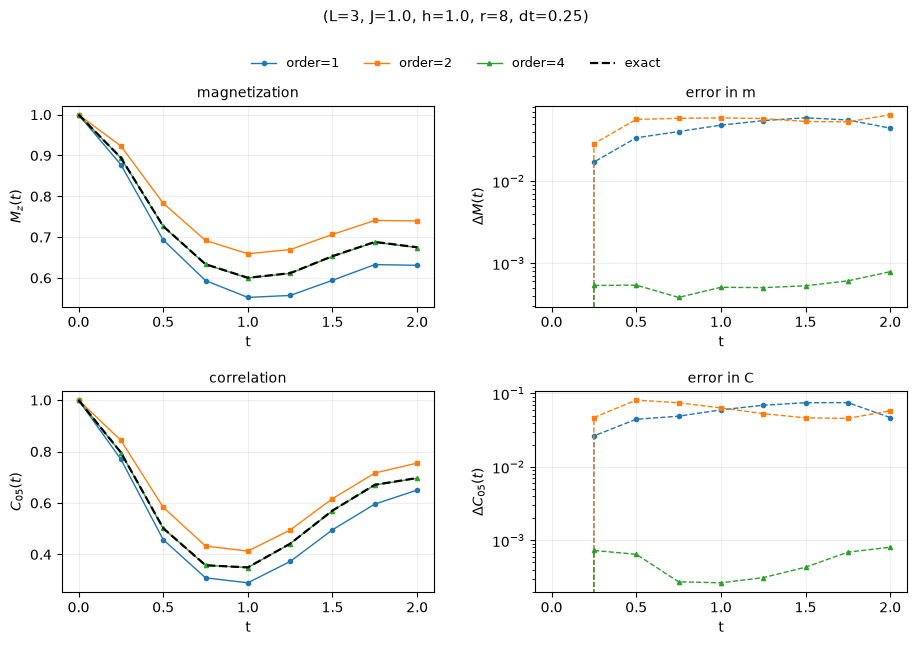

In [8]:
## Plots: without noise
param,qc = essentials_2(
        L,bonds, J_exc, h,
        T=2.0,r=8,
        i=0,j=5,
        p1=0.0,p2=0.0)

### Trotter evolution: recording M and C for each dt step ##
res_1   = Trotter_evolution_s(basic, param, qc, noise="no" ,T_Order = 1)
res_2   = Trotter_evolution_s(basic, param, qc, noise="no" ,T_Order = 2)
res_4   = Trotter_evolution_s(basic, param, qc, noise="no" ,T_Order = 4)


plot_results(res_1, res_2, res_4, param, J_exc, h,noise="no", tag='')

 
### 1.1 Key observations from the $\langle M \rangle$ and $\langle C_{ij}\rangle$ plots, with final T=2:

1. Trotterization— 1st order: The error (absolute) in $\langle M \rangle$ and $\langle C_{ij}\rangle$ is ~ 4e-2 for Trotter steps, r=8. (It decreases with increasing   'r' and becomes ~1e-4 for r=100.)

2. Trotterization— 2nd order: The nature of the error is same as the 1st order Trotterization and drops from 1e-2 to 1e-4 as we increase r=8 to r=100.

3. Comparison between 1st vs 2nd order: Even though the order magnitude of the error is comparable for both the cases, surprisingly often the 1st order has lower error than the 2nd order! Also we notice this pattern is not completely in sync in $\langle M \rangle$ and $\langle C_{ij}\rangle$. In fact the error in $\langle M \rangle$ is lower for the 1st order over almost the complete evolution, whereas for $\langle C_{ij}\rangle$ 2nd order starts to perform better beyond t~1. To investigate this we look at the infidelity below.

4. Trotterization— 4th order: This is so far the best decomposition among the three. Even for r=8 shows remarkable result with error ~ 1e-4 and infidelity ~1e-5. To achieve such accuracy in the first two cases we need r ~ 300. 

5.  All the error calculated here is absolute error with respect to the exact diagonalization result.

### 1.2 Analysing the infidelity (1-F)
#### (1-F) vs t:

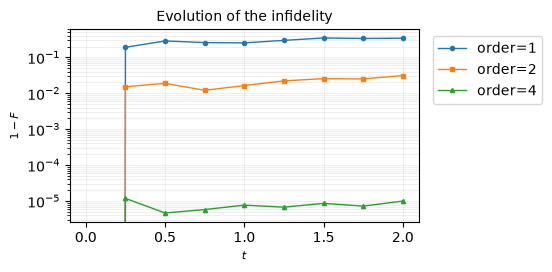

In [9]:
plot_IF(res_1, res_2, res_4, param, J_exc, h, tag='')

We find the infidelity is lower in 2nd order implying it to be more reliable. The fact that $\langle M \rangle$ and $\langle C_{ij}\rangle$ having lower error for some part of the evolution is due the local nature of the corresponding operators and therefore is not capable of capturing the complete error of the many-body wavefunction. Also the in $\langle M \rangle$ is lower in 1st order throughout the course of evolution is tied with such |00...000> initialization of the state which is an eigen state of the ZZ part of the Hamiltonian.
The infidelity in the 4th order is by far the lowest making it the best performing Trotterization at least in the noiseless case.

#### Scaling of (1-F) with r:
*Trotter_vs_r(basic, param, r_list, noise="no", T_Order = 1):*  
Calculates infidelity with varying Trotter step-sizes r. The arguments are as discussed before.

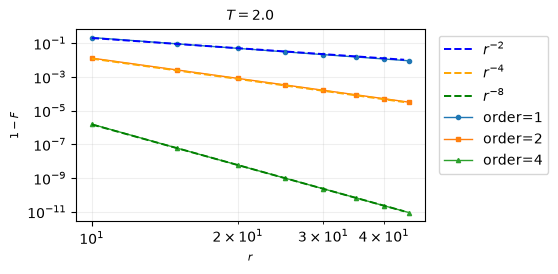

In [10]:
r_list=np.arange(10,50,5)
res_1_r   = Trotter_vs_r(basic, param, r_list, noise="no", T_Order = 1)
res_2_r   = Trotter_vs_r(basic, param, r_list, noise="no", T_Order = 2)
res_4_r   = Trotter_vs_r(basic, param, r_list, noise="no", T_Order = 4)
plot_results_F(res_1_r, res_2_r, res_4_r, param, J_exc, h,noise="no", tag='')

Here we show the scaling of (1-F) with the number of Trotter steps $r$. We find the order-1,2,4 follows the expected $\sim \mathcal{O}(r^{-2}), \mathcal{O}(r^{-4}), \mathcal{O}(r^{-8})$ respectively, which confirms that the trotterization is implemented correctly.


### 1.3 Conclusion for the noiseless case:
1. As long as local diagonal operator concerned there is no drastic gain in using 2nd order over 1st order Trotterization. In fact for lower values of final T 1st order performs better.
2. The infidelity confirms that the second order performs better than first order in general.
3. 4th order outperforms the first two. 


# 2. Simulation with noise

We introduce depolarizing noise with probabilities p1 and p2 corresponding to 1-qubit and 2-qubit gates respectively.

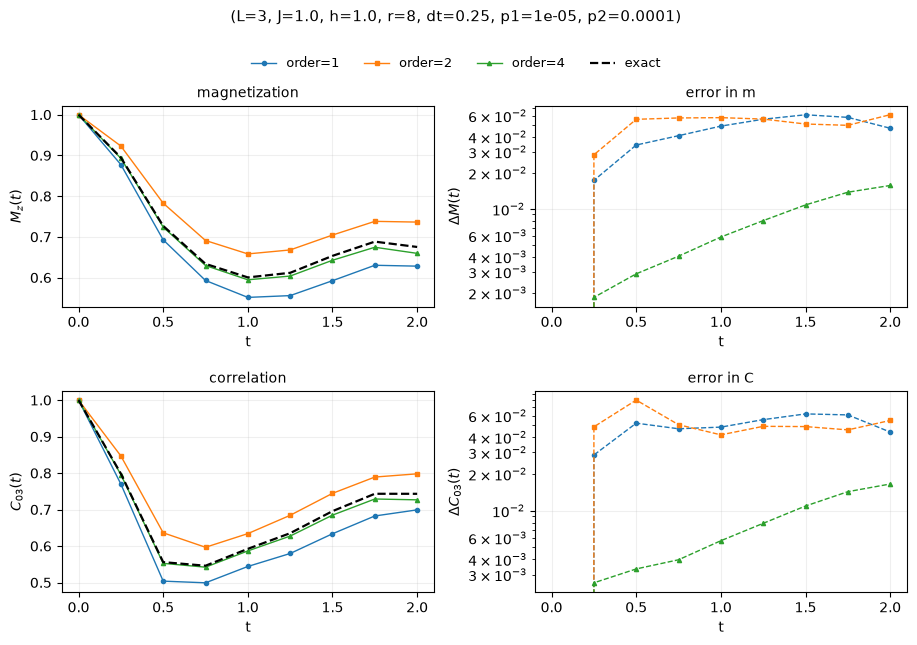

In [11]:
## Plots: with noise
## NOTE: needs the three noise="yes" runs in the main cell to be uncommented first.
## Plots: without noise
param,qc = essentials_2(
        L,bonds, J_exc, h,
        T=2.0,r=8,
        i=0,j=3,
        p1=1e-5,p2=1e-4)

res_1   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 1)
res_2   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 2)
res_4   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 4)

plot_results(res_1, res_2, res_4, param, J_exc, h,noise="yes", tag='')

### 2.1 Key observations from the $\langle M \rangle$ and $\langle C_{ij}\rangle$ plots, with final T=2:
We repeat our previous analysis with r=8 and final time T=2. We introduce noise with low error probabilities p1=1e-5, p2=1e-4:
1. For all the 1st, 2nd and 4th order Trotterization the error increases from the noiseless case. 

2. The error is noticeably increased in the 4th order reaching ~1e-2 at T=2. Whereas in the noiseless case it was ~1e-4. 
3. Over the finite time, the errors of the low orders stay roughly constant, while the fourth order error increases. 

### 2.2 Analysing the infidelity (1-F)
#### (1-F) vs t:

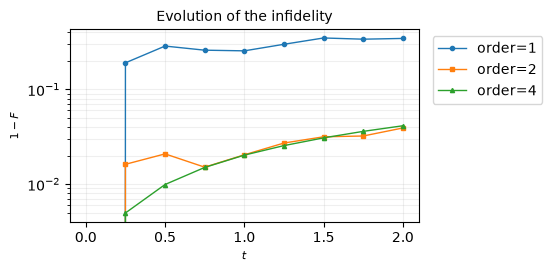

In [12]:
plot_IF(res_1, res_2, res_4, param, J_exc, h, tag='')

This plot shows very clearly 2nd order gradually starts to outperform the 4th order. The error increases drastically with increasing r. Next we will analyse that.

#### Scaling of (1-F) with r:

In [13]:
param,qc = essentials_2(
        L,bonds, J_exc, h,
        T=2.0,r=8,
        i=0,j=3,
        p1=1e-5,p2=1e-4)

r_list=np.arange(10,70,4)
res_1_r_ti   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 1)
res_2_r_ti   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 2)
res_4_r_ti   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 4)

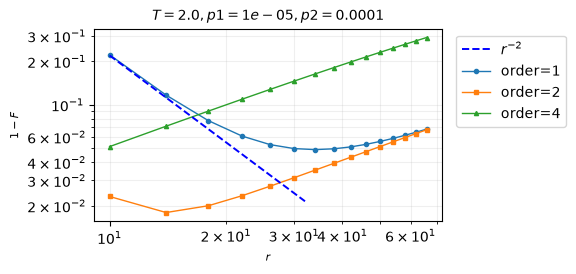

In [14]:
plot_results_F(res_1_r_ti, res_2_r_ti, res_4_r_ti, param, J_exc, h,noise="yes", tag='')

Key observations:

1. The noise free scaling completely breaks here. Still for early evolution time the scaling of ~$\mathcal{O}(r^{-2})$ is still visible. But for the rest it is destroyed even for the existence of such small error probabilities p1 and p2. This indicates that the noise error dominates the trotter error for higher orders.

2. Interestingly for 1st and 2nd order it looks like an optimal $r_{min}$ can be found for which the fidelity is minimal. In the next part of our analysis we investigate this $r_{min}$

### 2.3 Variation of $\Delta M_z$, $\Delta C$, (1-F) as a function r.
#### p1=1e-5, p2=1e-4

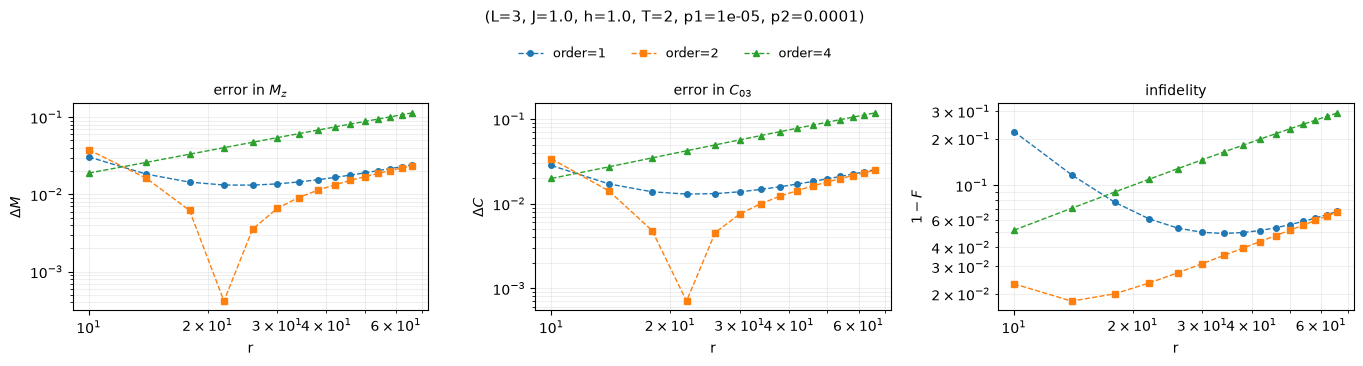

In [15]:
# P = plot_results_r(res_1_r, res_2_r, res_4_r, param, J_exc, h, tag='')
plot_results_r(res_1_r_ti, res_2_r_ti, res_4_r_ti, param, J_exc, h, tag='')

#### Key observations:

1. For local operators the same $r_{min} \sim 20$  that is capable of keeping the error reasonably low. 

2. This minimum is same for both $\Delta M$ and $\Delta C$ whereas differs in (1-F) making it clear again the different (nonlocal) nature of the last quantity.

Next, we repeat our analysis for increased error rates.

#### p1=1e-3, p2=1e-3

In [16]:
param,qc = essentials_2(
        L,bonds, J_exc, h,
        T=2.0,r=16,
        i=0,j=3,
        p1=1e-3,p2=1e-3)

# res_1   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 1)
# res_2   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 2)
# res_4   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 4)

# plot_results(res_1, res_2, res_4, param, J_exc, h, tag='')
r_list=np.arange(4,30,1)
res_1_r_sc   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 1)
res_2_r_sc   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 2)
res_4_r_sc   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 4)

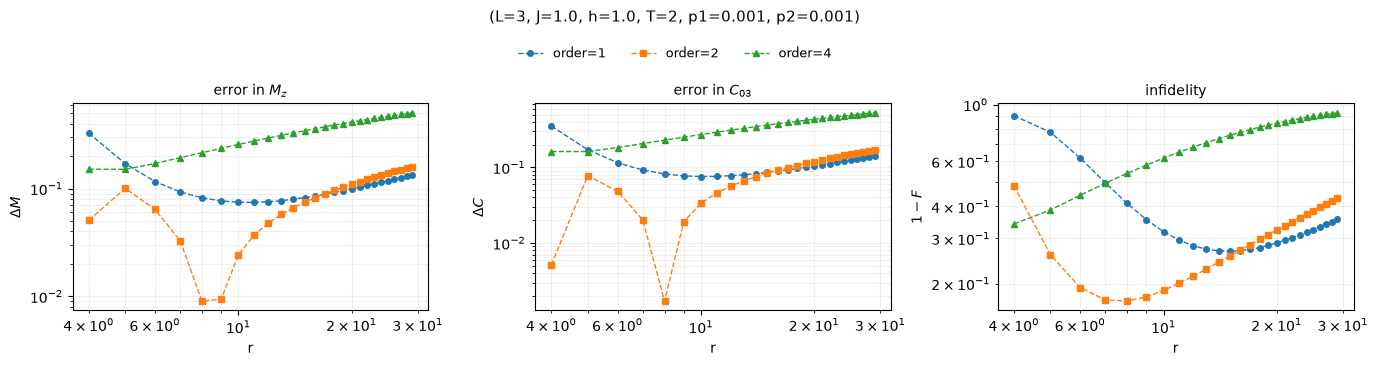

In [17]:
plot_results_r(res_1_r_sc, res_2_r_sc, res_4_r_sc, param, J_exc, h, tag='')

#### p1=3.0\*1e-3, p2=5.0\*1e-3

In [18]:
param,qc = essentials_2(
        L,bonds, J_exc, h,
        T=2.0,r=16,
        i=0,j=3,
        p1=3.0*1e-3,p2=5.0*1e-3)

# res_1   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 1)
# res_2   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 2)
# res_4   = Trotter_evolution_s(basic, param, qc, noise="yes" ,T_Order = 4)

# plot_results(res_1, res_2, res_4, param, J_exc, h, tag='')
r_list=np.arange(4,30,1)
res_1_r_n   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 1)
res_2_r_n   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 2)
res_4_r_n   = Trotter_vs_r(basic, param, r_list, noise="yes", T_Order = 4)

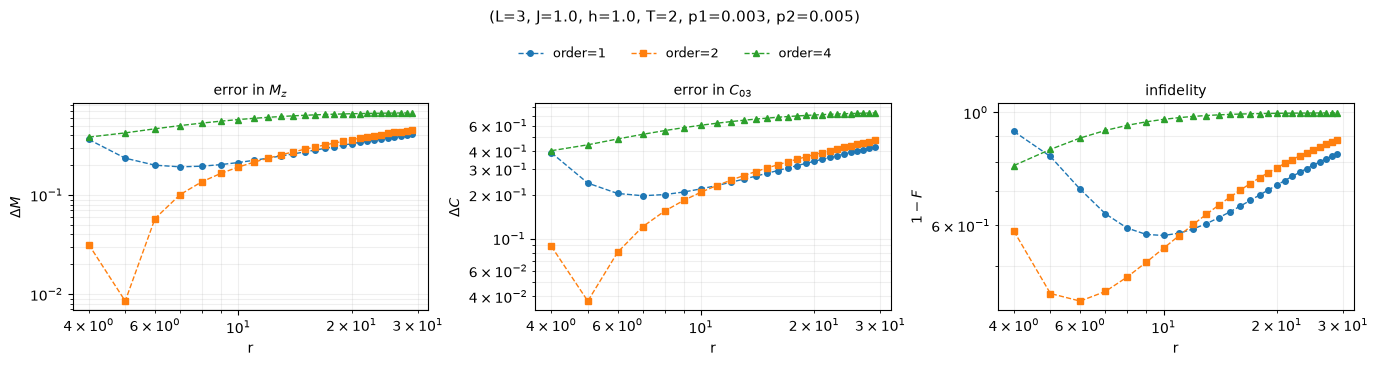

In [19]:
plot_results_r(res_1_r_n, res_2_r_n, res_4_r_n, param, J_exc, h, tag='')

### 2.4 Conclusion for the Trotterization with depolarizing noise:
1. 2nd order consistently performs better.

2. 4th order's performance is the worst. This indicates even higher order does not make sense.

3. For each choice of {p1,p2} we can find an optimal $r_{min}$ where at least the local observables has reasonably low error.

4. This $r_{min}$ decreases with increasing {p1,p2}. 

5. For our largest choice of p1=0.003 and p2=0.005, $r_{min}\approx 5$.

# Mapping our analysis in Quantum Processing Unit (QPU):
Our complete analysis is based on two types of evolution encoded in terms of 1-qubit and 2-qubit rotation $R_{zz}(\theta=-2J_{exc}dt)$ and $R_x(\theta=-2hdt)$ corresponding to $e^{-i\hat{H}_{zz}dt}$ and $e^{-i\hat{H}_{x}dt}$ respectively. In the following we briefly discuss how these gates can be implemented in the following QPUs.
### (a) In a superconducting quantum computer:
Lithographically fabricated circuits on a chip, using Josephson junctions as artificial atoms, controlled via microwave pulses.
1. Native 1-qubit gate (here $R_x(\theta)$) : Virtual/physical Z-rotations (essentially free, done via software frame changes) combined with microwave-driven X/Y rotations. 
2. Native 2-qubit gate : CNOT / CZ (fixed or tunable coupler)
3. $R_{ZZ}(\theta)$ implementation : CNOT.$I\otimes R_Z(\theta)$.CNOT
### (b) In a trapped-ion quantum computer: 
Individual charged atoms (ions) held in electromagnetic traps, with qubits encoded in their internal energy levels and entangled via shared vibrational (motional) modes. 
1. Native 1-qubit gate (here $R_x(\theta)$) : Single qubit rotations via laser or microwave pulses
2. Native 2-qubit gate :  Mølmer-Sørensen gate
3. $R_{ZZ}(\theta)$ implementation : Single qubit basis rotation + Native, single tunable pulse
### (c) In a neutral-atom quantum computer:
Individual neutral atoms held in optical tweezer arrays, entangled via temporary excitation to strongly-interacting Rydberg states.
1. Native 1-qubit gate (here $R_x(\theta)$) : Single qubit rotations via Raman or microwave transitions between hyperfine ground states
2. Native 2-qubit gate : Rydberg-blockade CZ i.e. a *fixed-angle* $CP(\pi)$
3. $R_{ZZ}(\theta)$ implementation : $CP(-2\theta)\cdot(R_Z(\theta)\otimes R_Z(\theta))$, up to global phase $e^{i\theta/2}$.

### **Optimal Trotter step ($r_{min}$) in the three platforms:**  
The three sets of {p1,p2} that we chose for our $r_{min}$ search  in practice corresponds to the three QPUs.
| Hardware | Estimated p1 and p2 (gate infidelity) | Optimal $r_{min}$ | Connectivity | Best suited for |
|---|---|---|---|---|
| **Superconducting** | ~1e-3,1e-3| ~8 |Fixed, nearest-neighbor (chip layout)| Fast, deep circuits; moderate fidelity |
| **Trapped-ion** | ~1e-5,1e-4 |~22 | All-to-all | High-fidelity circuits, small-to-moderate size |
| **Neutral-atom** | ~3e-3,5e-3 |~5 | Fully reconfigurable (movable atoms) | Large, flexible, or exotic 2D/3D geometries |




**References for noise parameters:**

1. S. J. Evered et al., "High-fidelity parallel entangling gates on a neutral-atom quantum computer," *Nature* **622**, 268–272 (2023).
2. A. C. Hughes et al., "Trapped-ion two-qubit gates with >99.99% fidelity without ground-state cooling," *arXiv:2510.17286* (2025).
3. S. Endo, S. C. Benjamin, Y. Li, "Practical Quantum Error Mitigation for Near-Future Applications," *Phys. Rev. X* **8**, 031027 (2018).

# Final discussion

## State-of-the-art classical methods:
| Method | Strength | Limitation |
|---|---|---|
| Exact Diagonalization (ED) | Exact | Exponential scaling with $L^2$ (In my local computer the ED part breaks down even for 4*4)|
| Tensor Network (MPS/TEBD) | Very efficient in studying 1D models | Entanglement growing exponentially with real-time evolution, making even modest system sizes hard for long T. Also contraction can be challenging for 2D. |
| Quantum Monte Carlo (QMC)| The best method for sign free equilibrium state | Breaks down in sign problem from frustrated systems and in dynamical sign problem. | 
| Neural Network (NN)| Flexible and not limited by entanglement| High computational cost. Time evolution becomes model dependent. | 



## Where a QPU could plausibly help, within noise constraints

1. No memory limitation: QPUs resource requirement scales with qubit count, not Hilbert-space dimension, so it does not have any exponential cost in L.

2. No entanglement limitation: unlike MPS, a QPUs cost doesn't grow with the entanglement of the state itself, making genuinely volume-law-entangled 2D dynamics tractable in principle on any of the three platforms.

3. Sign agnostic: Naturely more suited than QMC or NN.

## When QPU becomes competitive
1. To compete with ED only moderate system sizes are needed. For instance L=6-7 is already beyond the reach of ED, whereas all the three QPU's mentioned earlier can easily scale to such L.

2. TN methods can not capture evolution in higher T. While these methods are continously improving they will likely not go beyond T~20. (?) ( It is hard to estimate these numbers if TN also considers allowed to make approximations to trade inaccuracy for computational resources.)

## Error mitigation

Gate-infidelity is highest for neutral-atom and superconducting platforms ($p_2\sim10^{-3}$–$5\times10^{-3}$) relative to trapped-ion ($p_2\sim10^{-4}$–$10^{-3}$), so mitigation is most valuable on the former two. Mitigation helps a noisy circuit to get closer to the noiseless result.

Following techniques can be applied:
1.  Zero-noise extrapolation (running the circuit at several artificially amplified noise levels and extrapolating back to zero) 

2.  Probabilistic error cancellation can reduce the effective error rate without requiring new hardware. 

However, both of them needs sampling overhead. Given the optimal Trotter step count $r_{min}$ identified in Part (v) is already set by a tight balance between Trotter error and accumulated gate noise, mitigation could shift this optimum to somewhat larger $r$ (allowing a few more Trotter steps, or slightly longer evolution time $T$, before noise dominates). 
Altogether, error mititagtion would be helpful in improving the quality of results.